In [4]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from sim_wrapper.sim import Sim
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Qt5Agg')
%matplotlib inline

In [82]:
sim = Sim(use_complex=False)

sim.add_param('w_0', 6e9 * 2 * np.pi)
sim.add_paramsweep('amp_in', 0, 0.5, 50) # signal amplitude
sim.add_param('amp_block', 0.1) # signal amplitude
sim.add_paramsweep('phi_max', 0, 5, 2) # pump amplitude
sim.add_param('kappa', 0.5e9 * 2 * np.pi)  # mode decay rate
sim.add_param('kappa_r', 1e8 * 2 * np.pi) # filter bandwidth
sim.add_paramsweep('phase_in', 0, 2*np.pi, 21)
sim.add_param('phase_block', 0)
sim.add_param('w_pump', 12e9*2*np.pi), # pump frequency factor
sim.add_param('phi_DC', 1.5)
sim.add_param('w_J', 3e9 * 2 * np.pi)
sim.add_paramsweep('w_in', 5e9*2*np.pi, 7e9*2*np.pi, 31, is_excitation=True) # signal frequency
sim.add_param('w_block', 6.2e9*2*np.pi) # signal frequency

sim.add_EOM('x1', 'x2')
sim.add_EOM('x2', '-kappa*x2 - w_0**2*x1 - w_J**2*( sin(x1 + phi_DC) - sin(phi_DC) - cos(phi_DC)*x1) + 2*kappa*(-amp_in*w_in*cos(w_in*t + phase_in) -amp_block*w_block*cos(w_block*t + phase_block) - phi_max*w_pump*cos(w_pump*t))')
sim.add_EOM('x3','x2 + amp_in*w_in*cos(w_in*t + phase_in) + amp_block*w_in*cos(w_block*t + phase_block) + phi_max*w_pump*cos(w_pump*t)')

sim.set_solve_type('decimate')

sim.specify_time(20, 400, d_factor=1)

sim.validate()

Simulation validation success!


Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!


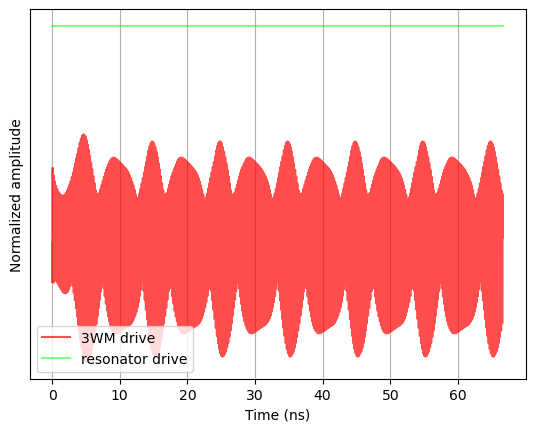

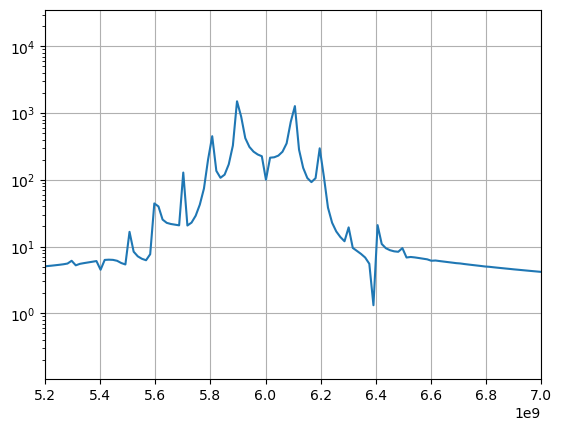

In [83]:
sim.param_dict_nosweep['w_in'] = 5.9e9*2*np.pi
sim.param_dict_nosweep['w_block'] = 5.8e9*2*np.pi

x, t = sim.quick_trace()

plt.figure(1)
plt.clf()
plt.plot(t*1e9, x[0,:]/np.max(x[0,:]),color=(1,0,0,0.7),label='3WM drive')
plt.plot(t*1e9, x[2,:]/np.max(x[1,:])+2,color=(0,1,0,0.5),label='resonator drive')
plt.xlabel('Time (ns)')
plt.ylabel('Normalized amplitude')
plt.legend()
plt.yticks([])
plt.grid()

plt.figure(2)
fftx = np.fft.fft(x[2, :])
freqs = np.linspace(0, len(t)/t[-1], len(t))
plt.semilogy(freqs, np.abs(fftx).transpose())
plt.xlim([5.2e9, 7e9])
plt.grid()



In [ ]:
I, Q, t = sim.solve()

In [6]:
np.shape(I)

(3, 50, 2, 21, 31, 400)

C:\Users\boris\AppData\Local\Temp\ipykernel_268272\1676262304.py:3: RuntimeWarning: invalid value encountered in divide
  phase = np.arctan(Q/I)
C:\Users\boris\AppData\Local\Temp\ipykernel_268272\1676262304.py:22: RuntimeWarning: divide by zero encountered in divide
  pwrgain = 20*np.log10(amp_max[modeN,:,1,:,-1]/amp_max[modeN,:,0,:,-1])


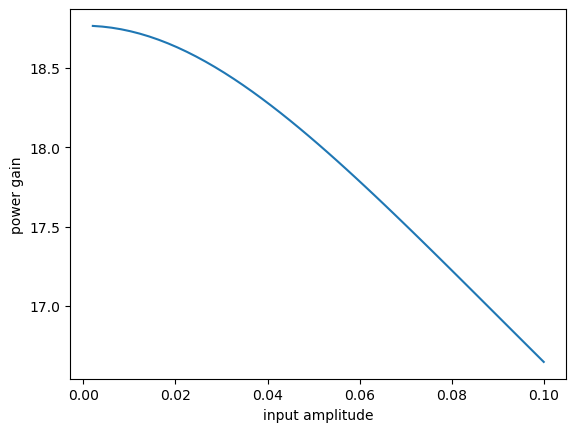

In [7]:
amp_max = np.max(np.sqrt(I**2 + Q**2), axis=3)
amp_min = np.min(np.sqrt(I**2 + Q**2), axis=3)
phase = np.arctan(Q/I)

modeN = 2

# plt.figure()
# pwrgain = 20*np.log10(amp_max[modeN,:,1,:,-1]/amp_max[modeN,:,0,:,-1])
# plt.pcolor(sim.paramsweep_dict['w_in']/(2*np.pi), sim.paramsweep_dict['amp_in'], pwrgain, cmap='seismic')
# plt.colorbar()
# plt.clim([-20,20])
# plt.contour(sim.paramsweep_dict['w_in']/(2*np.pi), sim.paramsweep_dict['amp_in'], pwrgain,'k--', levels=[20])

# plt.figure()
# pwrgain = 20*np.log10(amp_min[modeN,:,1,:,-1]/amp_min[modeN,:,0,:,-1])
# plt.pcolor(sim.paramsweep_dict['w_in']/(2*np.pi), sim.paramsweep_dict['amp_in'], pwrgain, cmap='seismic')
# plt.colorbar()
# plt.clim([-20,20])
# plt.contour(sim.paramsweep_dict['w_in']/(2*np.pi), sim.paramsweep_dict['amp_in'], pwrgain,'k--', levels=[20])

plt.figure()
pwrgain = 20*np.log10(amp_max[modeN,:,1,:,-1]/amp_max[modeN,:,0,:,-1])
plt.plot(sim.paramsweep_dict['amp_in'][1:], pwrgain[1:,len(sim.paramsweep_dict['w_in'])//2])
plt.xlabel('input amplitude')
plt.ylabel('power gain')
phi_max_i = 25
phase_i = 0